# Generate source cataloges 

You can use this notebook as a starting point to generate your PlatoSim simulations needed for your GO proposal(s). This notebook build on the information from the `LightCurve.ipynb` tutorial.

Author: Nicholas Jannsen

Last checked: 2026-01-30

PlatoSim version: `3.7.0-165-gae316c48`

In [24]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
# Python standard
import os
import sys
import glob

# PlatoSim standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.coordinates import SkyCoord
from astropy import units as u

# PlatoSim functions
import platosim.plot      as pt
import platosim.utilities as ut 
import platosim.starquery as sq
from platosim.lightcurve   import LightCurve
from platosim.utilities    import getFunctions
from platosim.matplotlibrc import setup_notebook
setup_notebook()

# Configure notebook 
from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [26]:
# Set global paths
# hdir = Path(os.getenv('PLATO_PROJECT_HOME')) / 'inputfiles/data_picsim'
path = Path(os.getenv('PLATO_WORKDIR')) / 'go_gmode'
idir = path / 'input'
odir = path / 'output'
fdir = path / 'figures'
ddir = path / 'data'

---
## Test of added benefit of Plato for Kepler targets
---

Date for first Kepler exposure: 54964.5120606 MJD = 2009-05-13 12:16:45.938 UTC

Date for first Plato exposure: 61904.51164280 MJD = 2028-05-13 12:16:45.938 UTC (assume 19 year later)


### Select a KIC

In [27]:
# kic = 'KIC5557072'
kic = 'KIC9244992'

### Create varsource file

<IPython.core.display.Javascript object>


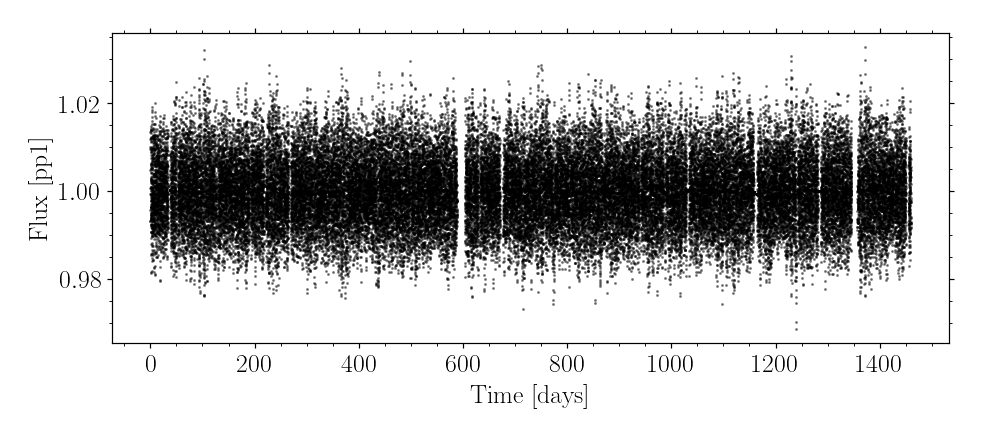

In [28]:
# Load Kepler light curve
df_kepler = pd.read_csv(ddir / f'{kic}_light_curves.dat', sep='   ', names=['time', 'flux'])
df_kepler.time -= df_kepler.time.min()
# Plot light curve
plt.figure(figsize=(9,4))
plt.plot(df_kepler.time, df_kepler.flux, 'ko', ms=1, alpha=0.4)
plt.xlabel('Time [days]')
plt.ylabel('Flux [pp1]')
plt.tight_layout();

<IPython.core.display.Javascript object>


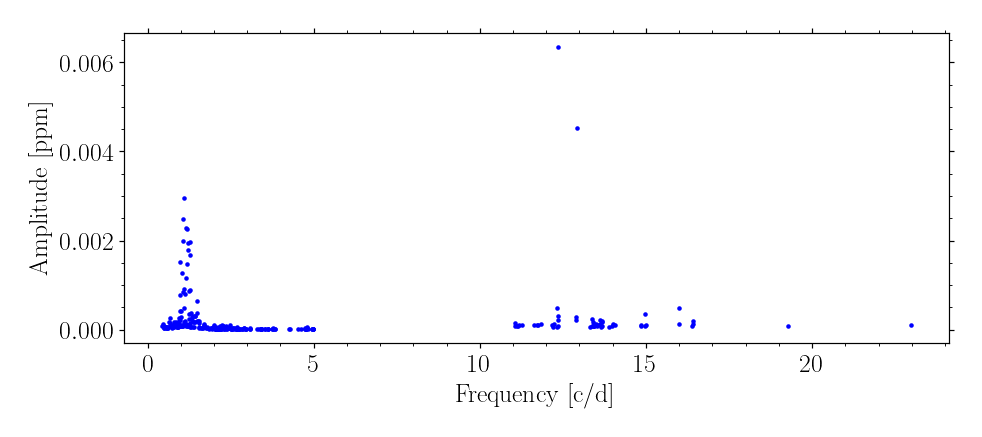

In [29]:
# Load extracted modes
dm = pd.read_csv(ddir / f'{kic}very_deep_clean.dat', 
                 sep=' ', skiprows=1, names=['freq', 'ampl', 'phase', 'snr']).dropna()
# Plot modes
plt.figure(figsize=(9,4))
plt.plot(dm.freq, dm.ampl, 'bo', ms=2)
plt.xlabel('Frequency [c/d]')
plt.ylabel('Amplitude [ppm]')
plt.tight_layout();

In [30]:
# Generate light curve from modes
time = np.arange(0, 21*ut.year()/86400, 25/86400)
flux = np.zeros_like(time)
N = dm.shape[0]
for i in range(N):
    flux += dm.ampl[i] * np.cos(2*np.pi * dm.freq[i] * time - dm.phase[i])
flux += 1
dv = pd.DataFrame({'time': time, 'flux':flux})

<IPython.core.display.Javascript object>


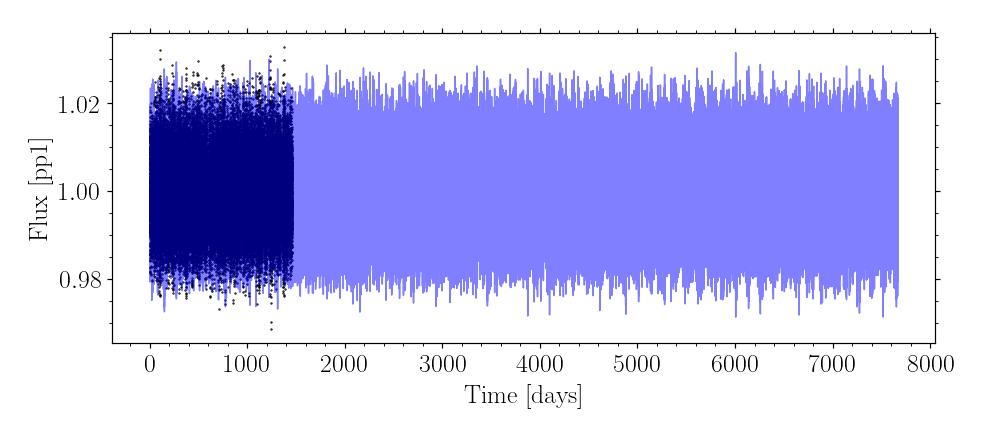

In [31]:
# Show light curve into Plato era
plt.figure(figsize=(9,4))
plt.plot(df_kepler.time, df_kepler.flux, 'k.', ms=1)
plt.plot(dv.time, dv.flux, '-', c='b', lw=1, alpha=0.5);
plt.xlabel('Time [days]')
plt.ylabel('Flux [pp1]')
plt.tight_layout();

In [32]:
# Take last two years and save template
nexp = round(2 * ut.year() / 25)
df = dv.copy()
df = df.loc[df.shape[0]-nexp:]
df.time -= df.time.iloc[0]
df.time *= 86400
df.flux = -2.5 * np.log10(dv.flux)
df = df.reset_index(drop=True)
df.to_csv(idir / f'varsource_{kic}.txt', sep=' ', index=False, header=False)

### Reduce Plato simulations

In [34]:
# Load light cruves
lcs = LightCurve(odir/kic , mode='multi')
files = lcs.files(suffix='ftr')
files[0]

'/lhome/nicholas/software/workdir/go_gmode/output/KIC9244992/000000001_Ncam1.1_Q1.ftr'

In [35]:
# Create table with simulation statistics
dt = lcs.stat_sim_table(ofile=odir/kic/f'table_{kic}.ftr', clean=True)
dt.head()

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.06it/s]                


,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR,NSR
0,1,2.082209e+18,300.489295,45.62096,13.737704,1,1,1,3,1330.388761,2041.548322,11.917207,25.246998,-45.732130,19,0.032097,0.021408
1,1,2.082209e+18,300.489295,45.62096,13.737704,1,1,2,1,2481.026017,2856.119569,12.632645,-45.958468,31.069848,19,0.017828,0.019685
2,1,2.082209e+18,300.489295,45.62096,13.737704,1,1,5,3,1330.213303,2041.618153,11.916625,25.243839,-45.730873,19,0.032392,0.021321
3,1,2.082209e+18,300.489295,45.62096,13.737704,1,1,6,1,2481.048728,2856.174354,12.632598,-45.958877,31.068862,19,0.017318,0.019809
4,1,2.082209e+18,300.489295,45.62096,13.737704,1,2,1,3,1341.989386,2052.607567,11.901116,25.455809,-45.533064,19,0.031597,0.020388


<IPython.core.display.Javascript object>


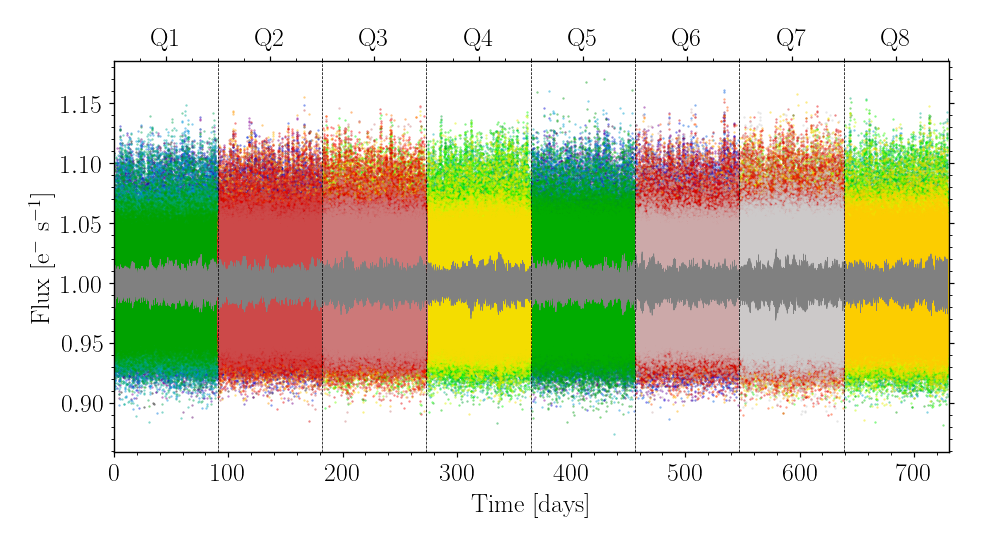

In [36]:
# Show all light curves
fig, ax = lcs.plot_multi(suffix='ftr', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.5, figsize=(9,5));

In [37]:
# Post-processing into final light curve
lc = lcs.merge(
    suffix='ftr',
    flux_group_mean=True,
    binsize=600,
    flux_offset=True,
    flux_error=True,
    ofile= odir/kic/f'lc_{kic}.ftr'
)

Processing star ID 000000001
-------------------------------------------------------
Merging 96 light curves


100%|██████████████████████████████████████████████████| 96/96 [00:34<00:00,  2.80it/s]              


Sorting data after timings
Averaging data from same camera group
Binning data per 600s
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:46.595871 [h:mm:ss]
-------------------------------------------------------


In [38]:
# Get light curve and add time offset since Kepler
df_plato = lc.data()
df_plato.time /= 86400 
df_plato.time += 19 * ut.year() / 86400

<IPython.core.display.Javascript object>


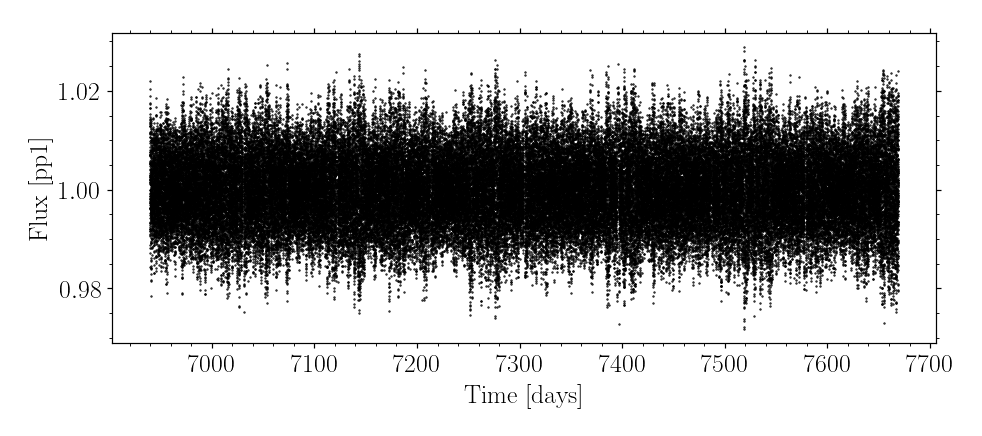

In [42]:
# Show Plato light curve
plt.figure(figsize=(9,4))
plt.plot(df_plato.time, df_plato.flux, 'k.', ms=1)
# plt.plot(dv.time, dv.flux, '-', c='b', lw=1, alpha=0.5);
plt.xlabel('Time [days]')
plt.ylabel('Flux [pp1]')
plt.tight_layout();

In [40]:
# Create new Kepler+Plato light curve
df_comb = pd.concat((df_kepler, df_plato))
df_comb.to_csv(ddir/f'{kic}_combined.csv', sep=',', index=False, header=True)

<IPython.core.display.Javascript object>


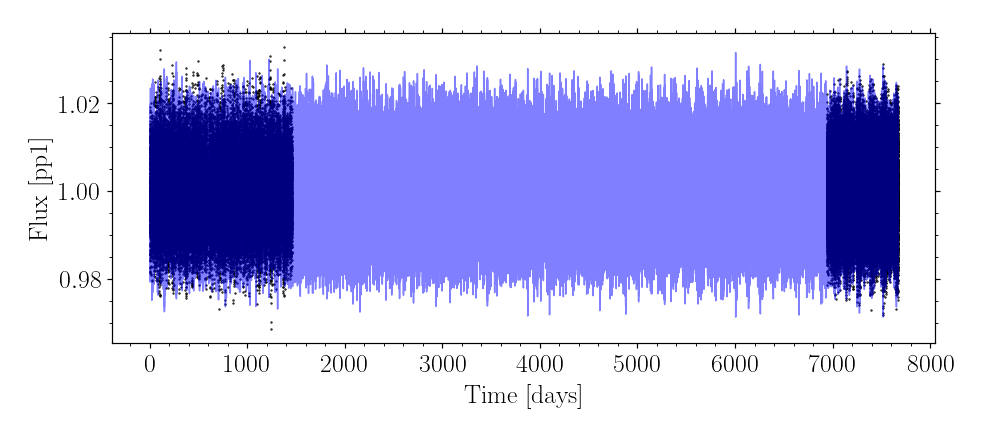

In [41]:
# Show light curve into Plato era
plt.figure(figsize=(9,4))
plt.plot(df_comb.time, df_comb.flux, 'k.', ms=1)
plt.plot(dv.time, dv.flux, '-', c='b', lw=1, alpha=0.5);
plt.xlabel('Time [days]')
plt.ylabel('Flux [pp1]')
plt.tight_layout();

In [ ]:
sys.exit()

### Frequency extraction

In [ ]:
def starshadow(filename, snr_thres=5):
    import star_shadow as ss
    path = filename.parents[0] / 'starshadow'
    name = filename.stem
    # Perform prewhitening using STARSHADOW
    ss.analyse_lc_from_file(str(filename), save_dir=str(path), stage='freq',
                            overwrite=True, verbose=args.verbose, sn_thr=snr_thres)
    # Load file containing columns
    filename_hdf5 = path / f'{name}_analysis_2.hdf5' 
    result = ss.utility.read_parameters_hdf5(filename_hdf5, verbose=args.verbose)
    # Save data into feather file
    mean = result['sin_mean']
    err  = result['sin_err']
    snr  = result['sin_select']
    df = pd.DataFrame()
    df['freq']       = mean[2]      # [c/d]
    df['freq_err']   = err[2]       # [c/d]
    df['ampl']       = mean[3]*1e6  # [ppm]
    df['ampl_err']   = err[3]*1e6   # [ppm]
    df['phase']      = mean[4]      # [rad]
    df['phase_err']  = err[4]       # [rad]
    df['passed_snr'] = snr[1]       # [bool]
    df = df.sort_values('freq').reset_index(drop=True)
    # Save feather with modes
    filename_mod = path / f'{name}_modes.ftr'
    df.to_feather(filename_mod)
    os.system(f'chmod 755 {filename_mod}')
    # Remove star shadow light curve
    filename_dat.unlink()
    os.system(f'rm -r {folder_hdf5}')

In [ ]:
# Extract frequencies of Kepler data
filename = odir/kic/f'lc_{kic}.dat'
filename.parents[0]

In [ ]:
# Extract frequencies of Kepler data
starshadow(odir/kic/f'lc_{kic}_kepler.dat', snr_thres=5)

In [ ]:
# Extract frequencies of Plato data
starshadow(odir/kic/f'lc_{kic}_plato.dat', snr_thres=5)

In [ ]:
# Extract frequencies of Kepler+Plato data
starshadow(odir/kic/f'lc_{kic}_combined.dat', snr_thres=5)

---
## 2. Benchmark $\gamma$ Dor and SPB stars
---

### Load catalogue

In [ ]:
filename = ddir / '20260130-SPB-GDOR-PLATO-GO-candidates.xlsx'
df = pd.read_excel(filename, skiprows=[1, 2, 3, 45, 46, 47])
dt = pd.DataFrame({
    'ID':df['#HDid'],
    'ra':df['RA(deg)'],
    'dec':df['Dec(deg)']
})

In [ ]:
dx = sq.simbadQuery(dt.ID.iloc[0], radius=15, maglim=21)
dx

In [ ]:
# Query sources from Gaia DR3 database
from tqdm import tqdm 
df = pd.DataFrame()
for n in tqdm(dt.ID, bar_format=ut.tqdmBar()):
    try:
        dx = sq.simbadQuery(n, radius=15, maglim=21)
    except:
        print(n)
        pass
    else:
        df = pd.concat([df, dx.iloc[0].to_frame().T])

In [ ]:
df['ID'] = dt.ID.to_numpy()

In [ ]:
df

In [ ]:
# Plot all stars in galactic projection
fig, ax = pt.drawStarsInSkyAitoff(df.ra, df.dec, column=df.Pmag, ms=10, figsize=(12,8))
fig.savefig(fdir / f'aitoff_gdor_and_spb.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot target in Galactic projection
# fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', ncamStars=True,
#                           raStars=df.ra, decStars=df.dec, magStars=df.Pmag)
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=29,
                          raStars=df.ra, decStars=df.dec, c=df.Pmag, ncamStars=True,
                          clabel=r'$\mathcal{P}$ [mag]', s=200, lw=0.25, figsize=(9,9),
                         title='Bright SPB and gDor stars in the LOPS2')
# fig.savefig(fdir / f'starcat_sky_targets_{filename}.png', bbox_inches='tight', dpi=200)

## Cross-match with LOPS2 

In [ ]:
ds = pd.read_feather(hdir / 'starcat_PlatoCS_NCAM_LOPS2.ftr')
ds.gaiaDR3 = ds.gaiaDR3.astype('float64')
ds.head()

In [ ]:
# Find stars within the LOPS2
df_match = df[df['gaiaDR3'].isin(ds['gaiaDR3'])].sort_values(by=['Gmag'])
df_match

In [ ]:
dx = df_match #.iloc[2]
# print(dx)
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', ncamStars=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, 
                          clabel=r'$\mathcal{P}$ [mag]', s=250, lw=0.5, 
                          figsize=(9,9), title='Bright SPB and gDor stars in the LOPS2')
fig.savefig(fdir / f'starcat_gdor_and_spb.png', bbox_inches='tight', dpi=200)

## Stars overlapping with F-CAMs

In [ ]:
ds_fcam = pd.read_feather(hdir / 'starcat_GaiaDR3_FCAM_LOPS2.ftr')

In [ ]:
dx = ds_fcam.loc[::100]
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', ncamStars=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, 
                          clabel=r'$\mathcal{P}$ [mag]', s=None, lw=0.5, 
                          figsize=(9,9), title='Bright SPB and gDor stars in the LOPS2')

## Cross-match with scvPIC

In [ ]:
dx = pd.read_csv(hdir / 'LOPS2scvPICtarget2.2.0.2.csv')

In [ ]:
# Add Galactic coordinates
gal = SkyCoord(dx.RAdeg, dx.DEdeg, frame='icrs', unit=u.deg).galactic
# Create data frame
df = pd.DataFrame()
df['PIC']     = dx.scvPICid
df['gaiaDR3'] = dx.StarName
df['l']       = gal.l.deg
df['b']       = gal.b.deg
df['ra']      = dx.RAdeg
df['dec']     = dx.DEdeg
df['pmra']    = dx.pmRA
df['pmdec']   = dx.pmDE
df['Pmag']    = dx.PlatoMagNCAM
# dt['PBmag']   = df.PlatoMagFCAMb
# dt['PRmag']   = df.PlatoMagFCAMr
# dt['M']       = df.Mass
# dt['R']       = df.Radius
# dt['Teff']    = df.Teff
# dt['logg']    = pic.get_logg()
df['ncams']   = dx.BOLnCameraObsNCAM_T
# dt['case']    = df.caseFlag
# df['source']  = dx.PICmainSourceFlagBOL
# dt['tPIC']    = df.tPICsourceFlagNCAM_BOL
# dt['fgPIC']   = df.fgPICsourceFlag
# dt['cPIC']    = df.cPICsourceFlag
df['scvPIC']  = dx.scvPICsourceFlag

In [ ]:
# Find stars within the LOPS2
df_scv = df_match[df_match['gaiaDR3'].isin(df['gaiaDR3'])].sort_values(by=['Gmag'])
df_scv

In [ ]:
dx = df
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', ncamStars=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, 
                          clabel=r'$\mathcal{P}$ [mag]', s=None, lw=0.5, 
                          figsize=(9,9), title='Bright SPB and gDor stars in the LOPS2')